# Lab 7 — Video World Model

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/overdued/world-model-spatial-intelligence-course/blob/main/labs/lab07_video_world_model/notebook_en.ipynb)

**World Models & Spatial Intelligence · Hands-on Lab 7**

Labs 2–3 learned **latent dynamics**: compress an image into a low-dimensional state `z` and predict the future in latent space.
This lab pushes the same problem to its **generative form**: **video prediction** directly at the pixel level.
Give the model the first 5 frames and let it **generate** the next 10.

```
frames x₁..x₅ ──CNN Encoder──▶ ConvGRU (temporal dynamics) ──CNN Decoder──▶ predicted frames x̂₆..x̂₁₅
```

This is the minimal skeleton of a **video world model**. Large video models such as VideoGPT, Genie and Sora conceptually do
the same thing, **generating future frames from past frames**, only with a diffusion / transformer backbone
and internet-scale video data. On this 70k-parameter model you will see the fundamental challenge of video world models
with your own eyes: **long-horizon drift**. The further ahead the prediction, the blurrier and more divergent it gets (Lab 10 quantifies this systematically).

## 1. Motivation: why is video prediction the generative form of a world model?

At its core, a world model is **a model that can "imagine" the future**. Lab 2 imagined in latent space (decoding `ẑ_{t+1}` back into an image was only an after-the-fact check),
whereas video prediction makes generating future frames the task itself:

- **As representation learning**: to predict future frames, the model has to internalize physical regularities such as "shapes move at constant velocity and bounce off walls". Prediction is scaffolding for learning the structure of the world;
- **As a generative world model**: the idea behind Genie / Sora is that by learning "how the world evolves" from huge amounts of video, the model itself becomes an interactive simulator you can sample from.

But video prediction has two fundamental difficulties, and this lab leaves them nowhere to hide:

1. **Multimodal futures**: the same past can have many plausible futures. A deterministic model trained with MSE / BCE can only output "the average of all possible futures", which shows up as **blurriness**;
2. **Compounding error / drift**: predicted frames are fed back into the model as the next input, so every small error gets amplified, which shows up as **rollouts that diverge the longer they run**.

> **Teaching point:** video prediction is the generative form of a world model; long-horizon drift is its fundamental challenge (connects to Lab 10).

## 2. Setup

**Why this cell exists:** The only dependencies are PyTorch (CPU is enough), NumPy, Matplotlib and imageio (for saving GIFs), all preinstalled on Colab; anything missing locally is installed automatically. All experiments finish on a laptop CPU within a few minutes.

In [1]:
# @title setup
import sys, subprocess

def ensure(pkg, import_name=None):
    try:
        __import__(import_name or pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

for pkg, name in [("torch", "torch"), ("imageio", "imageio")]:
    ensure(pkg, name)

import os
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import imageio.v2 as imageio
from IPython.display import HTML
from matplotlib.animation import FuncAnimation
from matplotlib.path import Path as MplPath

%matplotlib inline
os.makedirs("assets", exist_ok=True)
torch.manual_seed(0)
np.random.seed(0)
print("torch", torch.__version__, "| device: cpu")

torch 2.14.0+cu130 | device: cpu


## 3. Environment & Dataset: Moving Shapes

**Why not Moving MNIST:** Moving MNIST requires downloading ~800MB of data, while all we need is the minimal physics of "several objects moving with inertia + bouncing off walls".
Following the same simulator approach as Labs 0/2/10, we generate **Moving Shapes** directly in code:

- 3 shapes per video, **circle / square / triangle**, with identities distinguished by gray levels 1.0 / 0.75 / 0.5;
- each shape has a random initial position, direction and speed, and **bounces elastically** off walls;
- each video is **16 frames of 48×48 grayscale**; the first `CTX=5` frames are the context input, and the model predicts the next `FUT=10` frames (the last frame is kept as a buffer).

Task definition: **input frames 1–5 → predict frames 6–15**. This is the standard setup in the video prediction literature (Srivastava et al. 2015, "unsupervised learning of video representations").

In [2]:
SIZE, T = 48, 16          # frame resolution, frames per video
CTX, FUT = 5, 10          # context frames / predicted frames (frame 16 kept as a buffer)
N_TRAIN, N_TEST = 768, 128

GRID = np.stack(np.meshgrid(np.arange(SIZE), np.arange(SIZE), indexing="ij"), -1).reshape(-1, 2)

def draw_circle(img, x, y, r, v):
    yy, xx = np.mgrid[0:SIZE, 0:SIZE]
    m = (xx - x) ** 2 + (yy - y) ** 2 <= r * r
    img[m] = np.maximum(img[m], v)

def draw_square(img, x, y, r, v):
    x0, x1 = int(max(0, x - r)), int(min(SIZE, x + r + 1))
    y0, y1 = int(max(0, y - r)), int(min(SIZE, y + r + 1))
    img[y0:y1, x0:x1] = np.maximum(img[y0:y1, x0:x1], v)

def draw_triangle(img, x, y, r, v):
    pts = np.array([[x, y - r], [x - 0.9 * r, y + 0.7 * r], [x + 0.9 * r, y + 0.7 * r]])
    m = MplPath(pts).contains_points(GRID).reshape(SIZE, SIZE)
    img[m] = np.maximum(img[m], v)

DRAW = [draw_circle, draw_square, draw_triangle]
GRAY = [1.0, 0.75, 0.5]   # circle brightest, triangle darkest: identity is encoded in the gray level

def make_video(rng, speed=1.0):
    # 3 shapes: random position / direction / speed, elastic wall bounces
    shapes = []
    for i in range(3):
        m = 7  # spawn margin
        pos = rng.uniform(m, SIZE - 1 - m, size=2)
        ang = rng.uniform(0, 2 * np.pi)
        sp = rng.uniform(1.0, 2.0) * speed
        shapes.append(dict(kind=i, pos=pos, r=rng.uniform(3.5, 5.5),
                           vel=sp * np.array([np.cos(ang), np.sin(ang)])))
    frames = np.zeros((T, SIZE, SIZE), np.float32)
    for t in range(T):
        for s in shapes:
            DRAW[s["kind"]](frames[t], s["pos"][0], s["pos"][1], s["r"], GRAY[s["kind"]])
            s["pos"] += s["vel"]
            for d in range(2):  # elastic bounce: reflect the position, flip the velocity
                lo, hi = s["r"], SIZE - 1 - s["r"]
                if s["pos"][d] < lo: s["pos"][d] = 2 * lo - s["pos"][d]; s["vel"][d] *= -1
                if s["pos"][d] > hi: s["pos"][d] = 2 * hi - s["pos"][d]; s["vel"][d] *= -1
    return frames

t0 = time.time()
rng = np.random.default_rng(0)
train_np = np.stack([make_video(rng) for _ in range(N_TRAIN)])
test_np = np.stack([make_video(np.random.default_rng(1000)) for _ in range(N_TEST)])
X_tr = torch.from_numpy(train_np).unsqueeze(2)   # (N, T, 1, 48, 48)
X_te = torch.from_numpy(test_np).unsqueeze(2)
print(f"train {tuple(X_tr.shape)}  test {tuple(X_te.shape)}  generated in {time.time() - t0:.1f}s")

train (768, 16, 1, 48, 48)  test (128, 16, 1, 48, 48)  generated in 1.9s


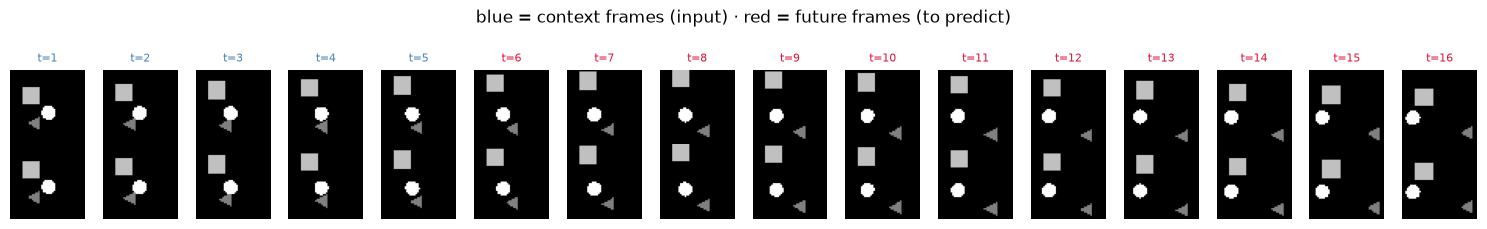

In [3]:
# two sample videos: 16 frames per row (first 5 = context, then the future)
fig, axes = plt.subplots(2, T, figsize=(15, 2.2))
for r in range(2):
    for t in range(T):
        axes[r, t].imshow(test_np[r, t], cmap="gray", vmin=0, vmax=1)
        axes[r, t].axis("off")
        if r == 0:
            axes[r, t].set_title(f"t={t+1}", fontsize=8,
                                 color="steelblue" if t < CTX else "crimson")
fig.suptitle("blue = context frames (input) · red = future frames (to predict)", y=1.02)
plt.tight_layout(); plt.show()

## 4. Build the Model: CNN Encoder → ConvGRU → Decoder

**Why this architecture:** Video prediction has to remember both "**what** is where" and "**how** it moves".
We upgrade Lab 2's Encoder–Dynamics–Decoder skeleton to a spatiotemporal version:

- **Encoder**: two stride-2 convs compress a 48×48 frame into a 32-channel 12×12 feature map, keeping the spatial structure (no flatten);
- **ConvGRU** (hand-written below, only 4 core lines): temporal dynamics on the feature map. The GRU's update/reset gates are all 3×3 convolutions, so the hidden state is itself a "spatial memory map":

$$z_t = \sigma(W_z * [x_t, h_{t-1}]), \quad r_t = \sigma(W_r * [x_t, h_{t-1}])$$
$$n_t = \tanh(W_n * [x_t,\; r_t \odot h_{t-1}]), \quad h_t = (1 - z_t) \odot n_t + z_t \odot h_{t-1}$$

- **Decoder**: two transposed convs decode the hidden state back into a 48×48 frame (outputting logits).

This is the GRU simplification of ConvLSTM (Shi et al. 2015, precipitation nowcasting); the whole model has only **~70k parameters** and trains on CPU alone.

In [4]:
H_CH = 32   # feature-map channels (12×12 spatial resolution)

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, 2, 1), nn.ReLU(),      # 48 -> 24
            nn.Conv2d(16, H_CH, 3, 2, 1), nn.ReLU(),   # 24 -> 12
        )
    def forward(self, x):
        return self.net(x)

class ConvGRUCell(nn.Module):
    # hand-written ConvGRU: gates are 3×3 convs, the hidden state is a (B, H_CH, 12, 12) spatial memory
    def __init__(self, in_ch, hid_ch):
        super().__init__()
        self.gates = nn.Conv2d(in_ch + hid_ch, 2 * hid_ch, 3, 1, 1)  # update z / reset r
        self.cand = nn.Conv2d(in_ch + hid_ch, hid_ch, 3, 1, 1)       # candidate n
    def forward(self, x, h):
        z, r = torch.sigmoid(self.gates(torch.cat([x, h], dim=1))).chunk(2, dim=1)
        n = torch.tanh(self.cand(torch.cat([x, r * h], dim=1)))
        return (1 - z) * n + z * h

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(H_CH, 16, 4, 2, 1), nn.ReLU(),  # 12 -> 24
            nn.ConvTranspose2d(16, 1, 4, 2, 1),                # 24 -> 48, raw logits
        )
    def forward(self, h):
        return self.net(h)

enc, gru, dec = Encoder(), ConvGRUCell(H_CH, H_CH), Decoder()
n_params = sum(p.numel() for m in (enc, gru, dec) for p in m.parameters())
print(f"parameters: {n_params:,}  (tiny — CPU-friendly)")

def predict_future(x, enc, gru, dec):
    # x: (B, T, 1, H, W). Warm up on the first CTX frames, then roll out FUT steps autoregressively:
    # each step decodes a predicted frame and re-encodes it into the GRU (the model eats its own predictions: training matches deployment)
    B = x.shape[0]
    h = torch.zeros(B, H_CH, SIZE // 4, SIZE // 4, device=x.device)
    for t in range(CTX):
        h = gru(enc(x[:, t]), h)
    preds, cur = [], x[:, CTX - 1]
    for t in range(FUT):
        logits = dec(h)
        preds.append(logits)
        cur = torch.sigmoid(logits)          # predicted frame becomes the next input (open-loop)
        h = gru(enc(cur), h)
    return torch.stack(preds, dim=1)         # (B, FUT, 1, H, W) logits

parameters: 68,657  (tiny — CPU-friendly)


## 5. Train: warmup + autoregressive rollout loss

**Why train this way:** Two common training strategies:

- **Teacher forcing**: feed the real frame at every step. The one-step loss looks great, but at deployment the model eats its own predictions, so the train/test input distributions differ (**exposure bias**) and rollouts collapse within a few steps;
- **What this lab does**: warm up on the first 5 real frames only, then **let the model eat its own predictions all the way**, with the loss applied to all 10 predicted frames. Training distribution = deployment distribution, so the model is forced to learn to "keep going despite its own errors".

The loss is `BCEWithLogitsLoss` + `pos_weight`: bright pixels cover only ~2% of the frame, and without reweighting the model gives up and outputs all black (the same lesson as Lab 2: sparse targets need loss reweighting).

step  100/600  rollout-BCE 0.5679


step  200/600  rollout-BCE 0.5309


step  300/600  rollout-BCE 0.4821


step  400/600  rollout-BCE 0.4619


step  500/600  rollout-BCE 0.4531


step  600/600  rollout-BCE 0.4292
trained in 970.8s on CPU


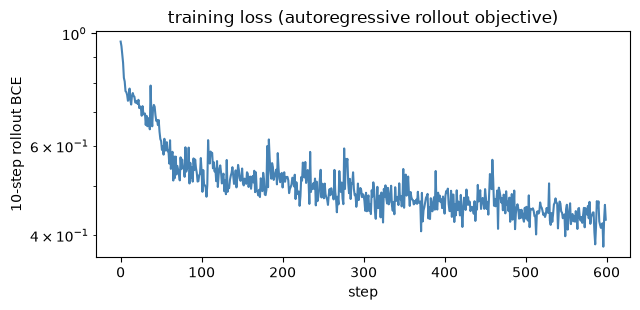

In [5]:
params = list(enc.parameters()) + list(gru.parameters()) + list(dec.parameters())
opt = torch.optim.Adam(params, lr=3e-3)
crit = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(5.0))

BATCH, STEPS = 16, 600
rng = np.random.default_rng(1)
losses = []
t0 = time.time()
for step in range(STEPS):
    idx = rng.choice(len(X_tr), BATCH, replace=False)
    xb = X_tr[idx]
    pred = predict_future(xb, enc, gru, dec)
    loss = crit(pred, xb[:, CTX:CTX + FUT])
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())
    if (step + 1) % 100 == 0:
        print(f"step {step+1:4d}/{STEPS}  rollout-BCE {loss.item():.4f}")

print(f"trained in {time.time() - t0:.1f}s on CPU")

plt.figure(figsize=(6.5, 3.2))
plt.plot(losses, color="steelblue")
plt.xlabel("step"); plt.ylabel("10-step rollout BCE"); plt.yscale("log")
plt.title("training loss (autoregressive rollout objective)")
plt.tight_layout(); plt.show()

## 6. Visualize: Ground Truth vs Prediction

**Qualitative results first.** Each episode below has two rows: **top = Ground Truth, bottom = Prediction** (the 5 columns on the left are the shared context frames).
Watch for three stages: the predicted frames are **right at first, then blurry, then scattered**. The shapes' positions start out correct, then the edges soften (uncertainty gets averaged), and finally several shapes smear into one blob.

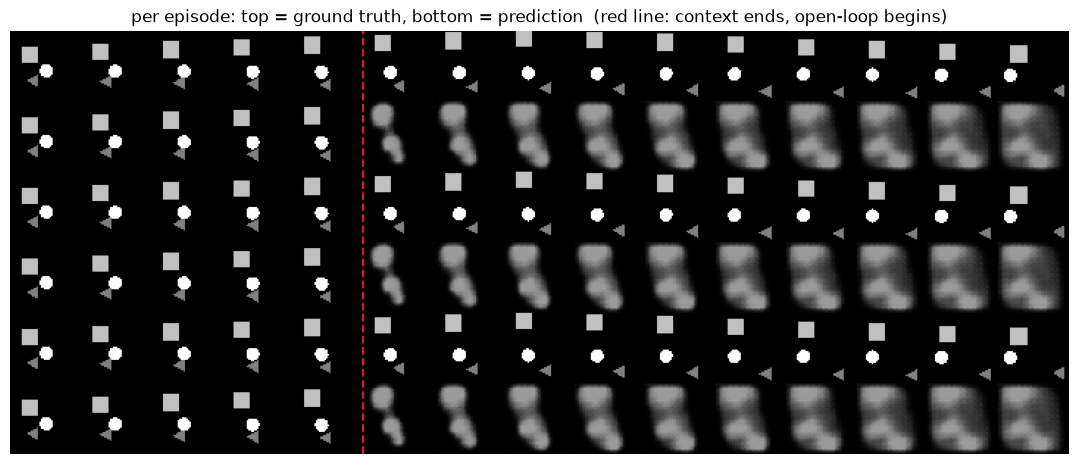

saved assets/gt_vs_pred.png and assets/prediction_rollout.gif


In [6]:
enc.eval(); gru.eval(); dec.eval()

with torch.no_grad():
    xb = X_te[:3]
    pred = torch.sigmoid(predict_future(xb, enc, gru, dec)).numpy()

rows = []
for b in range(3):
    ctx = xb[b, :CTX, 0].numpy()
    gt = xb[b, CTX:CTX + FUT, 0].numpy()
    pr = pred[b, :, 0]
    rows.append(np.concatenate(list(ctx) + list(gt), axis=1))
    rows.append(np.concatenate(list(ctx) + list(pr), axis=1))
grid = np.concatenate(rows, axis=0)

plt.figure(figsize=(15, 5.5))
plt.imshow(grid, cmap="gray", vmin=0, vmax=1)
plt.axvline(CTX * SIZE - 0.5, color="crimson", lw=1.5, ls="--")  # context | future boundary
plt.axis("off")
plt.title("per episode: top = ground truth, bottom = prediction  (red line: context ends, open-loop begins)")
plt.savefig("assets/gt_vs_pred.png", dpi=110, bbox_inches="tight")
plt.show()

# save a side-by-side GIF: GT on the left, prediction on the right, in sync
b = 0
ctx = xb[b, :CTX, 0].numpy()
gt = xb[b, CTX:CTX + FUT, 0].numpy()
pr = pred[b, :, 0]
side_by_side = [np.concatenate([ctx[t], ctx[t]], axis=1) for t in range(CTX)] + \
               [np.concatenate([gt[t], pr[t]], axis=1) for t in range(FUT)]
imageio.mimsave("assets/prediction_rollout.gif",
                [(f * 255).astype(np.uint8) for f in side_by_side], duration=0.3)
print("saved assets/gt_vs_pred.png and assets/prediction_rollout.gif")

fig = plt.figure(figsize=(4, 2))
plt.axis("off")
_im = plt.imshow(side_by_side[0], cmap="gray", vmin=0, vmax=1)
def _upd(i):
    _im.set_data(side_by_side[i]); return [_im]
_anim = FuncAnimation(fig, _upd, frames=len(side_by_side), interval=300, blit=True)
plt.close(fig)
HTML(_anim.to_jshtml())

## 7. Evaluate: per-frame error curve and rollout degradation

**Why quantify it:** The qualitative plots already show "the longer, the blurrier", but the deployment quality of a world model needs a curve to speak for it.
Run open-loop rollouts on the whole test set and measure the **MSE between the step-k predicted frame and the GT**:

- **1-step**: close to supervised prediction, the lowest error;
- **5-step**: errors start to accumulate, but the shapes are still recognizable;
- **10-step**: the error is several times the 1-step error, and predictions are close to "motion smear".

This curve is a direct measure of **compounding error / drift** (the latent version in Lab 2 and the OOD version in Lab 10 are the same phenomenon).

step:            1        2        3        4        5        6        7        8        9       10
pixel MSE: 0.02464  0.04019  0.05718  0.06547  0.07176  0.08048  0.08837  0.09591  0.10486  0.11219

1-step MSE 0.02464 | 5-step 0.07176 (2.9×) | 10-step 0.11219 (4.6×)


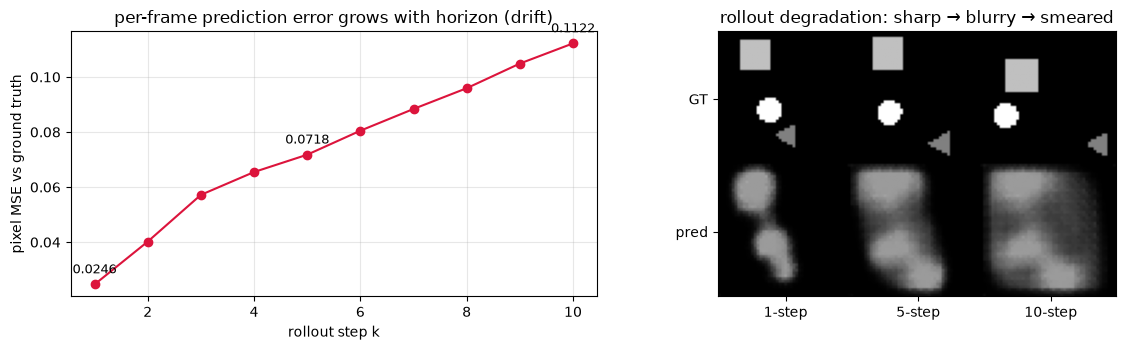

saved assets/rollout_degradation.png


In [7]:
with torch.no_grad():
    err_per_step = np.zeros(FUT)
    all_pred = []
    for i in range(0, len(X_te), 32):
        xb = X_te[i:i + 32]
        p = torch.sigmoid(predict_future(xb, enc, gru, dec))
        err_per_step += ((p - xb[:, CTX:CTX + FUT]) ** 2).mean(dim=(0, 2, 3, 4)).numpy() * len(xb)
        if i == 0:
            all_pred = p.numpy()
err_per_step /= len(X_te)

print("step:      " + "  ".join(f"{k+1:7d}" for k in range(FUT)))
print("pixel MSE: " + "  ".join(f"{e:.5f}" for e in err_per_step))
print(f"\n1-step MSE {err_per_step[0]:.5f} | 5-step {err_per_step[4]:.5f} "
      f"({err_per_step[4]/err_per_step[0]:.1f}×) | 10-step {err_per_step[9]:.5f} "
      f"({err_per_step[9]/err_per_step[0]:.1f}×)")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].plot(range(1, FUT + 1), err_per_step, "o-", color="crimson")
for k in [0, 4, 9]:
    axes[0].annotate(f"{err_per_step[k]:.4f}", (k + 1, err_per_step[k]),
                     textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
axes[0].set_xlabel("rollout step k"); axes[0].set_ylabel("pixel MSE vs ground truth")
axes[0].set_title("per-frame prediction error grows with horizon (drift)")
axes[0].grid(alpha=0.3)

# rollout degradation montage: 1 / 5 / 10-step predicted frames vs GT for the same episode
sel = [0, 4, 9]
b = 1
gt = X_te[b, CTX:CTX + FUT, 0].numpy()
row_gt = np.concatenate([gt[k] for k in sel], axis=1)
row_pr = np.concatenate([all_pred[b, k, 0] for k in sel], axis=1)
axes[1].imshow(np.concatenate([row_gt, row_pr], axis=0), cmap="gray", vmin=0, vmax=1)
axes[1].set_xticks([(i + 0.5) * SIZE for i in range(3)])
axes[1].set_xticklabels(["1-step", "5-step", "10-step"])
axes[1].set_yticks([SIZE // 2, 3 * SIZE // 2]); axes[1].set_yticklabels(["GT", "pred"])
axes[1].set_title("rollout degradation: sharp → blurry → smeared")
plt.tight_layout()
plt.savefig("assets/rollout_degradation.png", dpi=110, bbox_inches="tight")
plt.show()
print("saved assets/rollout_degradation.png")

## 8. Experiment: fast-motion stress test (drift × distribution shift)

**Guided experiment:** the model has only seen motion with speed ∈ [1, 2]. Now, without changing or retraining the model,
multiply the test set's speed by **2.5** (mild OOD: the same physics, faster motion) and rerun the same error curve:

- Prediction: the 1-step error already rises clearly (faster motion = larger frame-to-frame displacement = harder extrapolation), and drift grows more steeply;
- This previews Lab 10: **a one-step degradation looks mild, but a multi-step rollout amplifies it into failure**.

✏️ *Try it: change `SPEED_TEST` from 2.5 to 1.0 (ID control) or 4.0 (strong OOD) and watch how the shape of the curve transitions.*

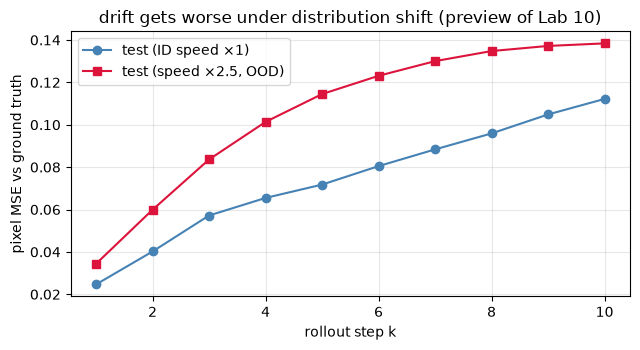

ID   : 1-step 0.02464 → 10-step 0.11219
×2.5: 1-step 0.03438 → 10-step 0.13840
saved assets/speed_stress.png


In [8]:
SPEED_TEST = 2.5
test_fast = torch.from_numpy(
    np.stack([make_video(np.random.default_rng(2000 + i), speed=SPEED_TEST)
              for i in range(N_TEST)])).unsqueeze(2)

with torch.no_grad():
    err_fast = np.zeros(FUT)
    for i in range(0, len(test_fast), 32):
        xb = test_fast[i:i + 32]
        p = torch.sigmoid(predict_future(xb, enc, gru, dec))
        err_fast += ((p - xb[:, CTX:CTX + FUT]) ** 2).mean(dim=(0, 2, 3, 4)).numpy() * len(xb)
err_fast /= len(test_fast)

plt.figure(figsize=(6.5, 3.6))
plt.plot(range(1, FUT + 1), err_per_step, "o-", color="steelblue", label="test (ID speed ×1)")
plt.plot(range(1, FUT + 1), err_fast, "s-", color="crimson", label=f"test (speed ×{SPEED_TEST}, OOD)")
plt.xlabel("rollout step k"); plt.ylabel("pixel MSE vs ground truth")
plt.title("drift gets worse under distribution shift (preview of Lab 10)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("assets/speed_stress.png", dpi=110, bbox_inches="tight")
plt.show()
print(f"ID   : 1-step {err_per_step[0]:.5f} → 10-step {err_per_step[9]:.5f}")
print(f"×{SPEED_TEST}: 1-step {err_fast[0]:.5f} → 10-step {err_fast[9]:.5f}")
print("saved assets/speed_stress.png")

## 9. Questions

1. **Where the blur comes from:** the model in this lab is deterministic and trained with per-pixel BCE. Why must long-range predictions become blurry?
   If the future itself is **multimodal** (one context has several plausible futures), what kind of model family avoids "averaging"?
   (Hint: how do diffusion / discrete-token sampling models avoid outputting the mean?)
2. **Exposure bias:** if training switched to teacher forcing (feeding real frames instead of predictions during rollout), would the one-step loss get better or worse?
   What about the 10-step rollout? Why?
3. **Action-conditioned variant:** give each frame a global "wind" action `a_t ∈ R²` (perturbing the velocities) and concatenate `a_t` into the GRU input.
   Once conditioned, what new path connects this model to the planning of Lab 4?
4. **Receptive field and long-range dependencies:** the ConvGRU's 3×3 convolutions propagate information by only 1 feature pixel per step. For larger scenes and longer horizons,
   why are transformer (global attention) or SSM-style architectures a better fit?

## 10. Takeaways

- **Video prediction is the generative form of a world model**: move the same Encoder → Dynamics → Decoder skeleton from latent space (Lab 2) to pixel space, and the model has to generate "how the world evolves" as frames you can watch.
- **The hand-written ConvGRU has only 4 core lines**, yet it is enough to learn "constant-velocity motion + wall bounces": 1-step predictions are on target and 5-step predictions are still recognizable.
- **Long-horizon drift is the fundamental challenge**: predicted frames fed back into the model → compounding error → 10-step error several times the 1-step error, and the frame sequence visibly goes from sharp to a blurry smear. This is not a bug but the inevitable result of deterministic pixel prediction + multimodal futures.
- **Training distribution = deployment distribution**: only when trained with an autoregressive rollout loss (not teacher forcing) does the model avoid being "spooked" by its own predictions.
- **Distribution shift amplifies drift**: a mild OOD of speed ×2.5 shifts the whole error curve up and makes it steeper. Quantifying this phenomenon systematically is the topic of Lab 10.

**Next:** Lab 8, using learned dynamics for navigation and planning; plus the literature map of large-scale video world models in the Advanced Extension.

## Advanced Extension: Diffusion / Transformer Video World Models (discussion only, nothing to run)

The ConvGRU in this lab is the technology of 2015–2017. Large-scale video world models took two routes, sketched below:

```
Route A — discrete tokens + transformer (VideoGPT → Genie)
video ──VQ-VAE tokenizer──▶ discrete token sequence ──autoregressive transformer──▶ future tokens ──decoder──▶ future frames
   Genie (2024): learns an action-controllable world model from unlabeled game videos; the latent actions are "learned"

Route B — continuous diffusion (Video Diffusion → Sora)
future frames (noise) ──denoising transformer (spacetime patches)──▶ future frames (clean)
   conditioning = context frames / text; iterative denoising naturally expresses multimodal futures, so no "averaging" and no blur
```

| | ConvGRU (this lab) | VideoGPT / Genie | Diffusion (the Sora approach) |
|---|---|---|---|
| Representing the future | a single point prediction (mean → blur) | a distribution over discrete tokens, can be sampled | continuous diffusion, can be sampled |
| Temporal modeling | frame-by-frame recursion, limited receptive field | global attention | global attention (spacetime patches) |
| Action conditioning | just concatenate to the input | latent actions (Genie) | text / control signals |

**Reading list (all real papers):**

- Srivastava et al. (2015), *Unsupervised Learning of Video Representations using LSTMs*. https://arxiv.org/abs/1502.04681 (the founding paper of video prediction)
- Shi et al. (2015), *Convolutional LSTM Network: A Machine Learning Approach for Precipitation Nowcasting*. https://arxiv.org/abs/1506.04214 (ConvLSTM)
- Denton & Fergus (2018), *Stochastic Video Generation with a Learned Prior* (SVG). https://arxiv.org/abs/1802.07687 (fighting blur with a stochastic latent)
- Yan et al. (2021), *VideoGPT: Video Generation using VQ-VAE and Transformers*. https://arxiv.org/abs/2104.10157
- Ho et al. (2022), *Video Diffusion Models*. https://arxiv.org/abs/2204.03458
- Bruce et al. (2024), *Genie: Generative Interactive Environments*. https://arxiv.org/abs/2402.15391 (an interactive world model learned from unlabeled video)
- OpenAI (2024), *Video generation models as world simulators* (Sora technical report). https://openai.com/research/video-generation-models-as-world-simulators

Course modules: [Scientist 10 · Video World Models](https://overdued.github.io/world-model-spatial-intelligence-course/en/docs/scientist/10-video-world-models) and [Scientist 10b · Interactive World Models](https://overdued.github.io/world-model-spatial-intelligence-course/en/docs/scientist/10b-interactive-world-models).